In [2]:
import pandas as pd

# Read CSV
order = pd.read_csv("/content/olist_order_payments_dataset.csv")



In [6]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 62.8 MB/s eta 0:00:00


In [3]:
order.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
order.shape

(103886, 5)

In [ ]:
# Validating the connection to mysql DB

In [8]:
import mysql.connector
from mysql.connector import Error

hostname = 'iuk338.h.filess.io'
database = 'Olist Project_villagejar'
port = 3307                 # ✅ must be int
username = 'Olist Project_villagejar'
password = '6eeed5ee7f123045a202e9d7e7d64666dd34c99c'

connection = None
cursor = None

try:
    connection = mysql.connector.connect(
        host=hostname,
        user=username,
        password=password,   # ✅ use password (not passwd)
        database=database,
        port=port            # ✅ include port
    )

    if connection.is_connected():
        db_info = connection.get_server_info()
        print("Connected to MySQL Server version:", db_info)

        cursor = connection.cursor()
        cursor.execute("SELECT DATABASE();")
        record = cursor.fetchone()
        print("You're connected to database:", record)

except Error as e:
    print(f"Error while connecting to MySQL:, {e}")

finally:
    if cursor is not None:
        cursor.close()

    if connection is not None and connection.is_connected():
        connection.close()
        print("MySQL connection is closed")


/tmp/ipython-input-3069070794.py:23: DeprecationWarning: Call to deprecated function get_server_info. Reason: 
    The property counterpart 'server_info' should be used instead.

  db_info = connection.get_server_info()


Connected to MySQL Server version: 8.0.36-28
You're connected to database: ('Olist Project_villagejar',)
MySQL connection is closed


In [36]:
hostname = 'iuk338.h.filess.io'
database = 'Olist Project_villagejar'
port = 3307                 # ✅ must be int
username = 'Olist Project_villagejar'
password = '6eeed5ee7f123045a202e9d7e7d64666dd34c99c'

connection = None
cursor = None

connection = mysql.connector.connect(
    host=hostname,
    user=username,
    password=password,   # ✅ use password (not passwd)
    database=database,
    port=port            # ✅ include port
)

In [35]:
#Create Table Query
cursor = connection.cursor()

create_table_query = '''
  DROP TABLE olist_order_payments_dataset;
  CREATE TABLE IF NOT EXISTS olist_order_payments_dataset (
    order_id VARCHAR(50),
    payment_sequential INT,
    payment_type VARCHAR(255),
    payment_installments INT,
    payment_value FLOAT)'''
cursor.execute(create_table_query)
connection.commit()
print("Table created successfully")

Table created successfully


In [37]:
#loading the order_payment dataset to filess.io
print('Order Payment set is being loaded...')

Order Payment set is being loaded...


In [38]:
#Inserting data in batches of 1000 records
batch_size = 500
total_records = len(order)
table_name = 'olist_order_payments_dataset'
try:
  print('Starting loading process...')
  for i in range(0, total_records, batch_size):
    end_index = i + batch_size
    batch_df = order.iloc[i:end_index]

    # Converting batch records into a list of tuples for MySQL insertion
    batch_records = [
        tuple(row) for row in batch_df.itertuples(index=False, name=None)


    ]

    #Prepare the insert query
    insert_query = f"INSERT INTO olist_order_payments_dataset (order_id, payment_sequential, payment_type, payment_installments, payment_value) VALUES (%s, %s, %s, %s, %s)"

    #Executing the insertion query
    cursor = connection.cursor()
    cursor.executemany(insert_query, batch_records)
    connection.commit()

    print(f'Inserted records {i + 1} to {min(end_index, total_records)}')
  print(f'All {total_records} was inserted into {table_name}')
except Error as e:
  print(f'Error while connecting to MySQL: {e}')

finally:
  if cursor is not None:
    cursor.close()

  if connection is not None and connection.is_connected():
    connection.close()
    print("MySQL connection is closed")
#

Starting loading process...
Inserted records 1 to 500
Inserted records 501 to 1000
Inserted records 1001 to 1500
Inserted records 1501 to 2000
Inserted records 2001 to 2500
Inserted records 2501 to 3000
Inserted records 3001 to 3500
Inserted records 3501 to 4000
Inserted records 4001 to 4500
Inserted records 4501 to 5000
Inserted records 5001 to 5500
Inserted records 5501 to 6000
Inserted records 6001 to 6500
Inserted records 6501 to 7000
Inserted records 7001 to 7500
Inserted records 7501 to 8000
Inserted records 8001 to 8500
Inserted records 8501 to 9000
Inserted records 9001 to 9500
Inserted records 9501 to 10000
Inserted records 10001 to 10500
Inserted records 10501 to 11000
Inserted records 11001 to 11500
Inserted records 11501 to 12000
Inserted records 12001 to 12500
Inserted records 12501 to 13000
Inserted records 13001 to 13500
Inserted records 13501 to 14000
Inserted records 14001 to 14500
Inserted records 14501 to 15000
Inserted records 15001 to 15500
Inserted records 15501 t

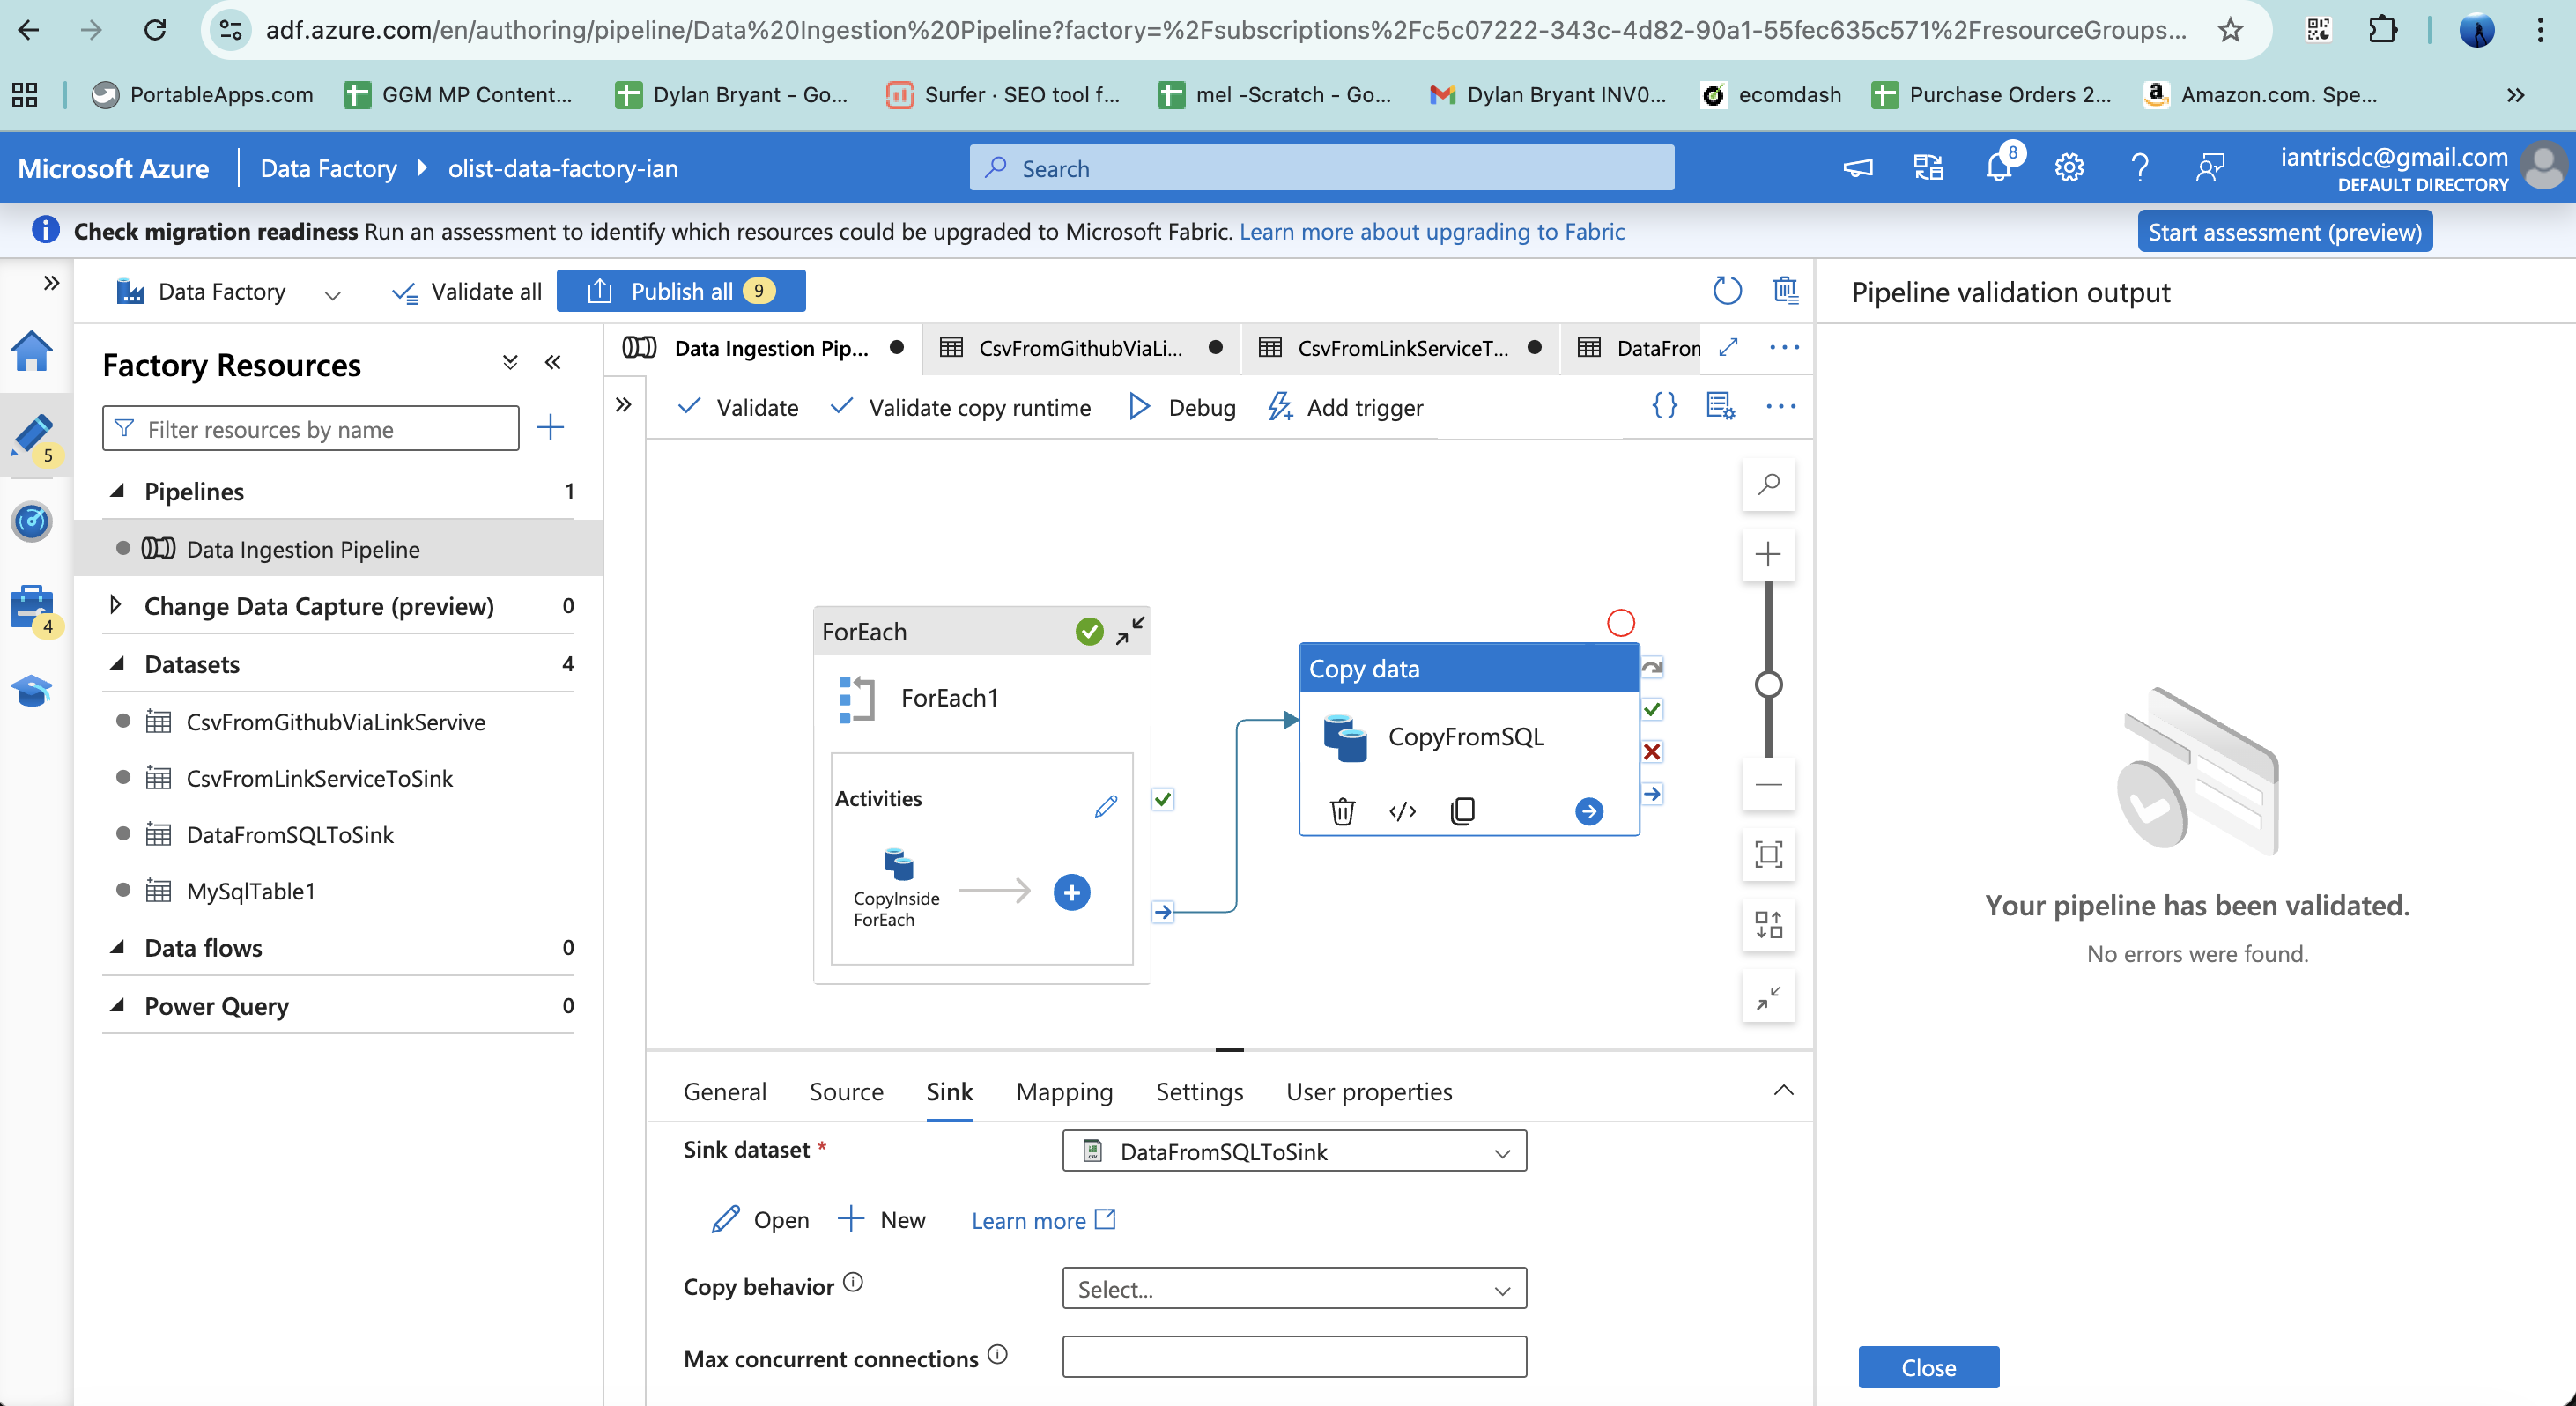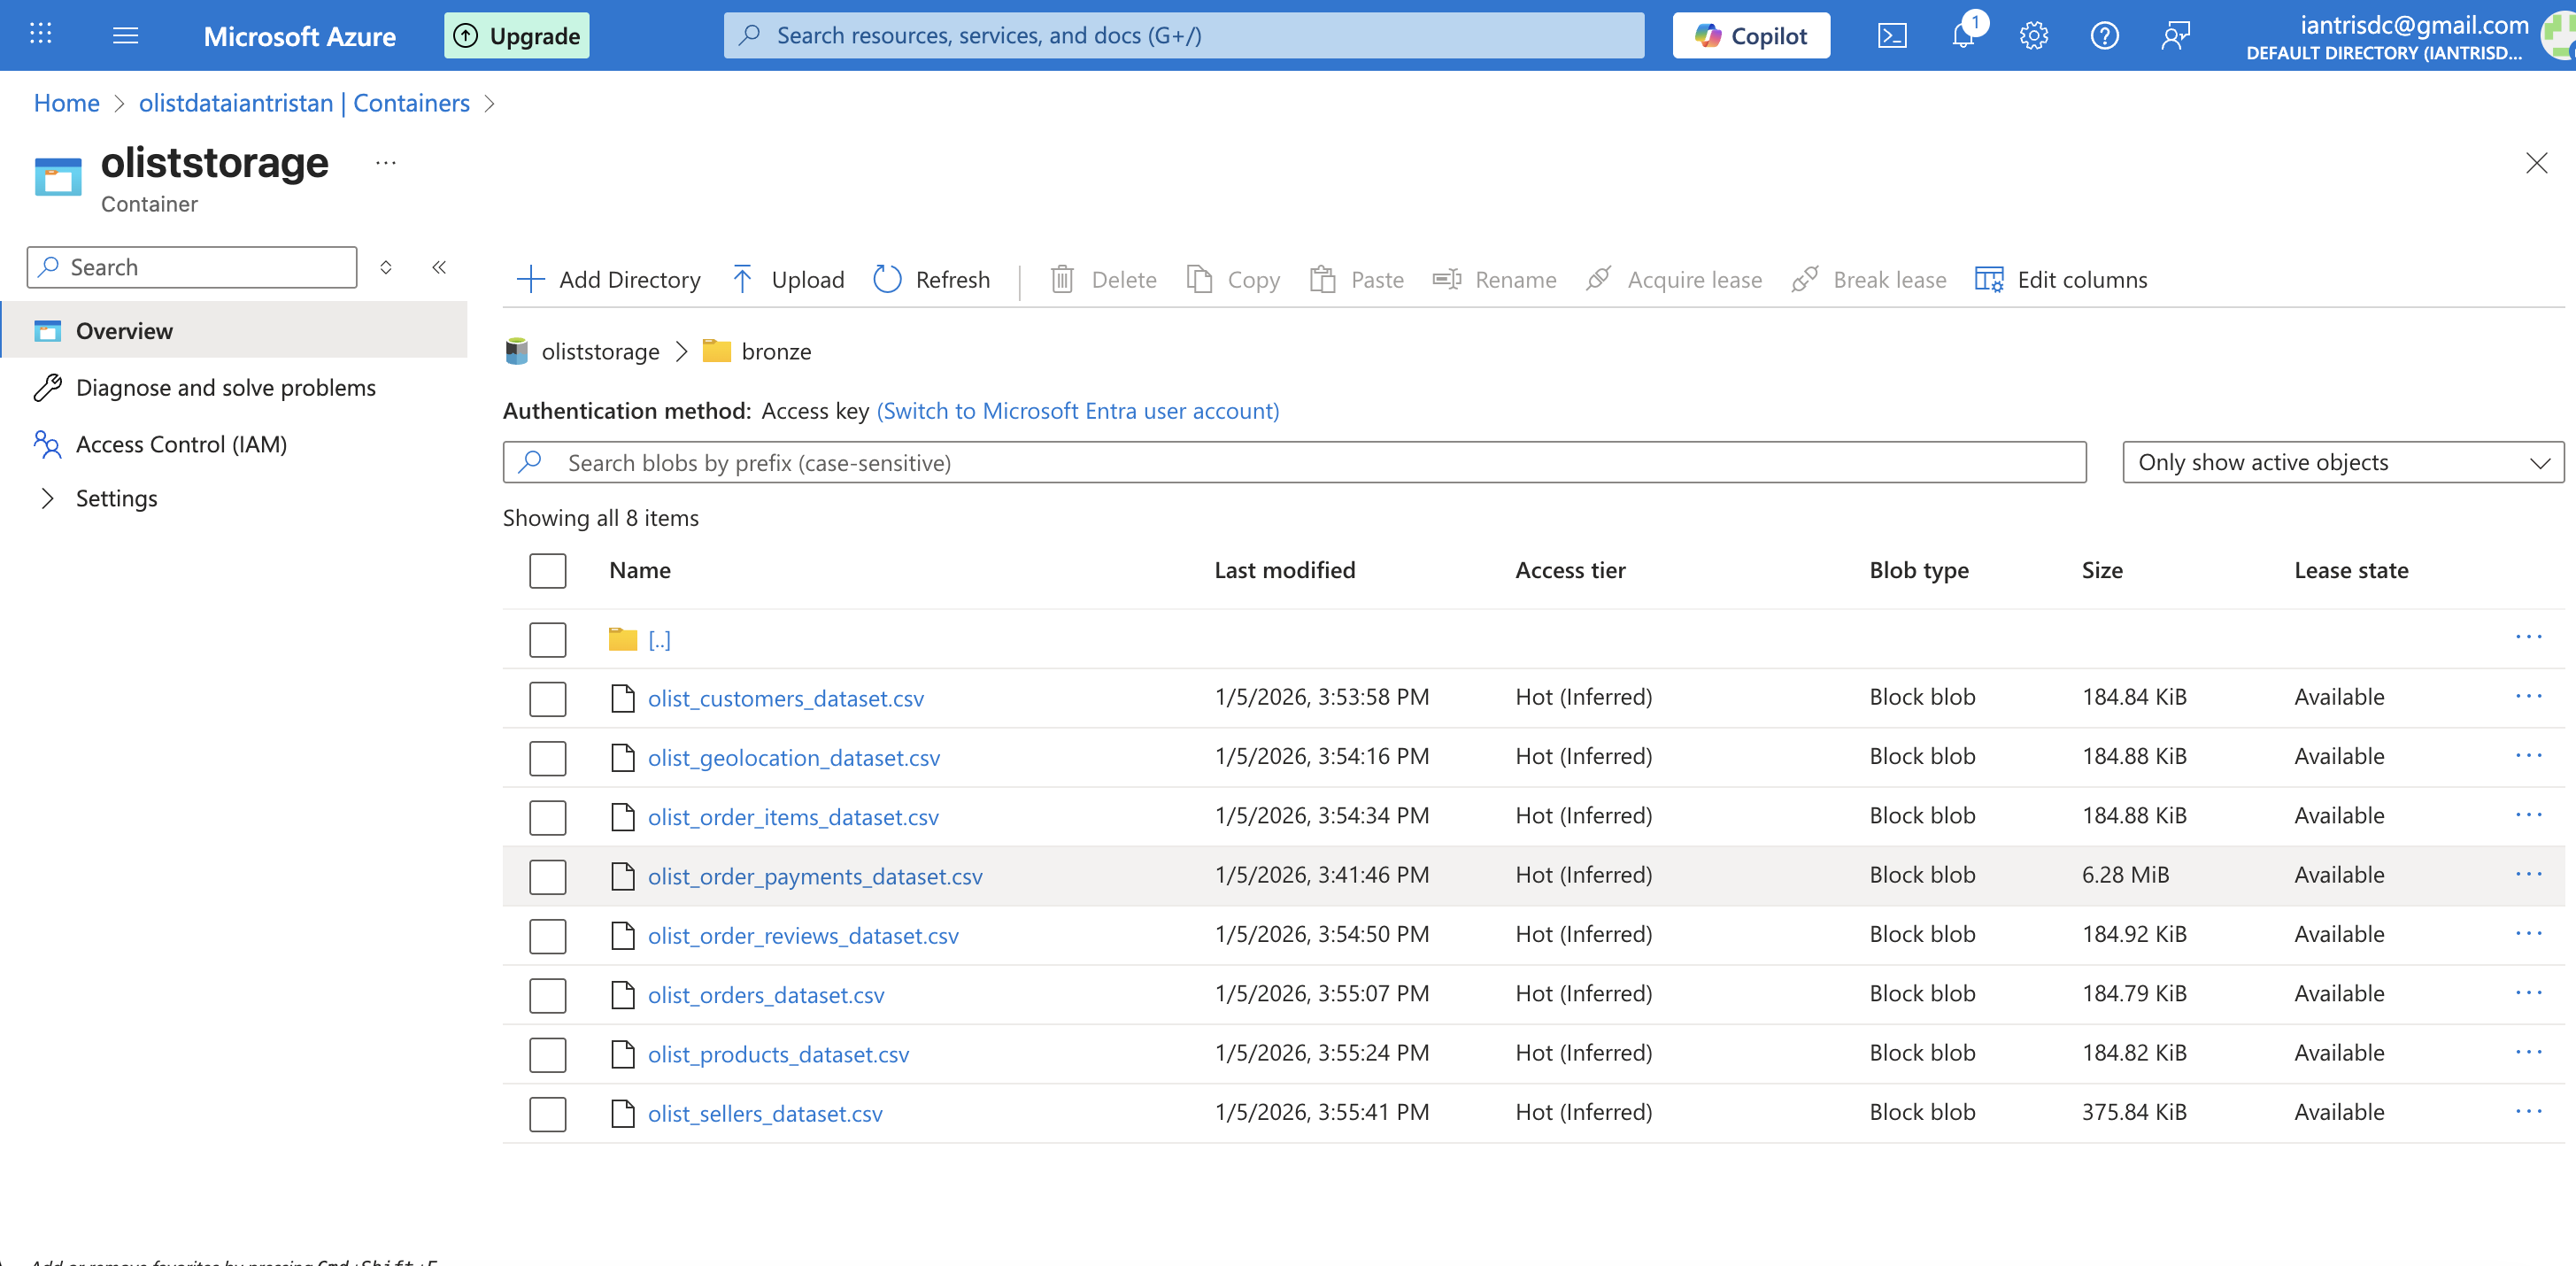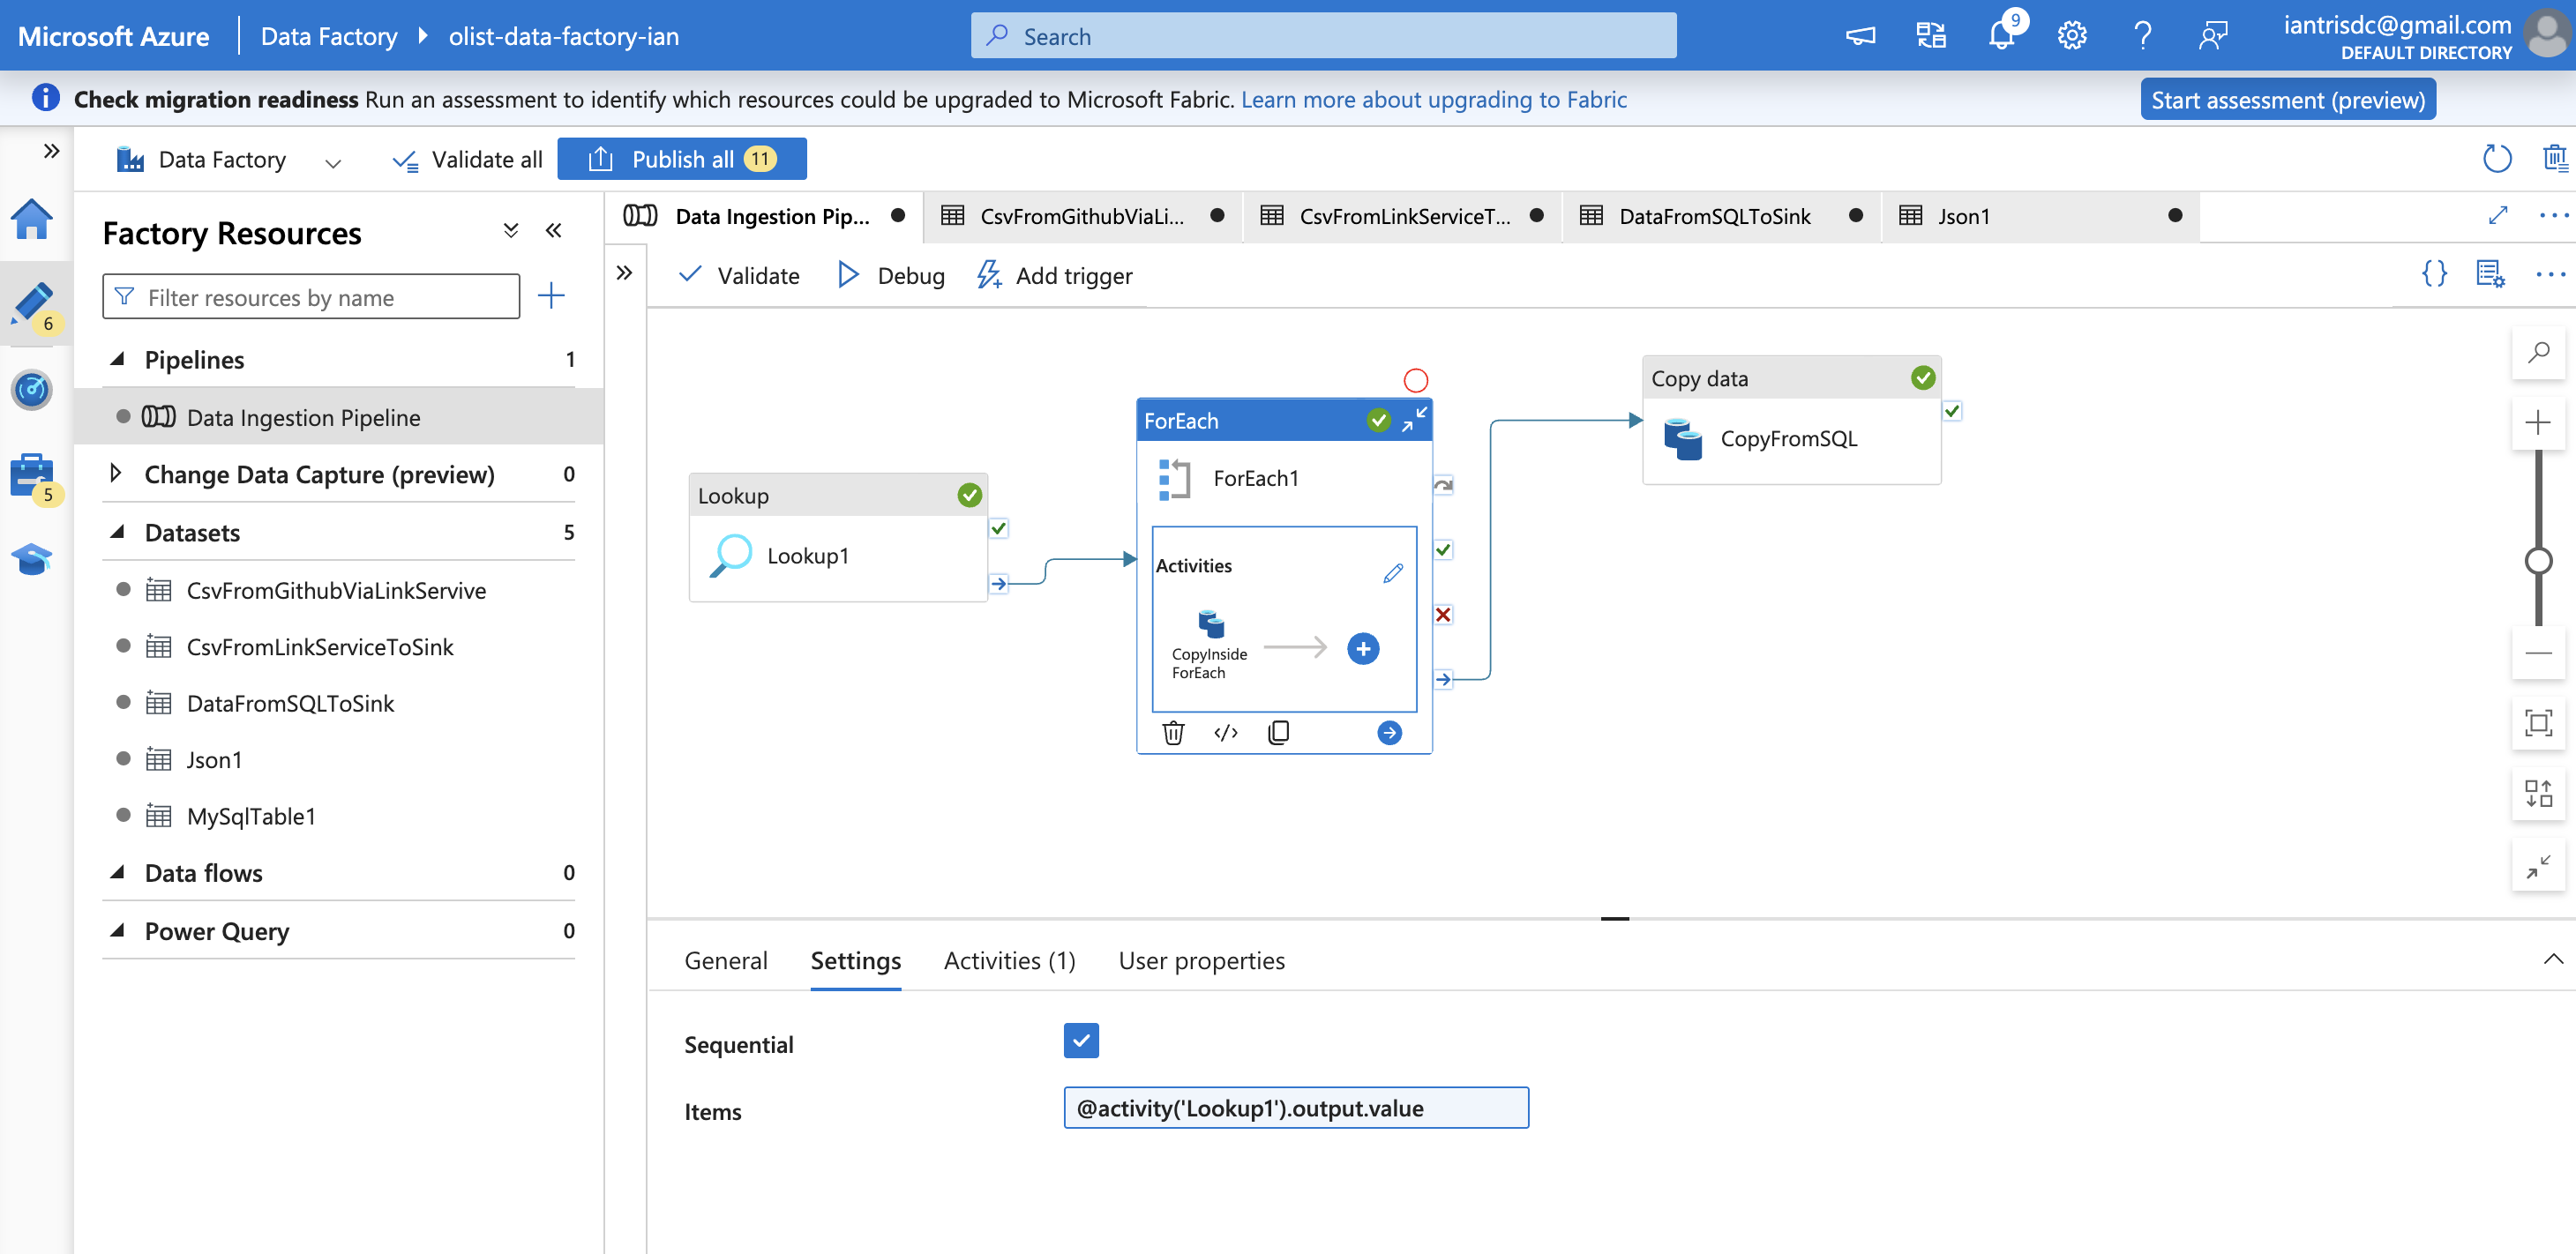

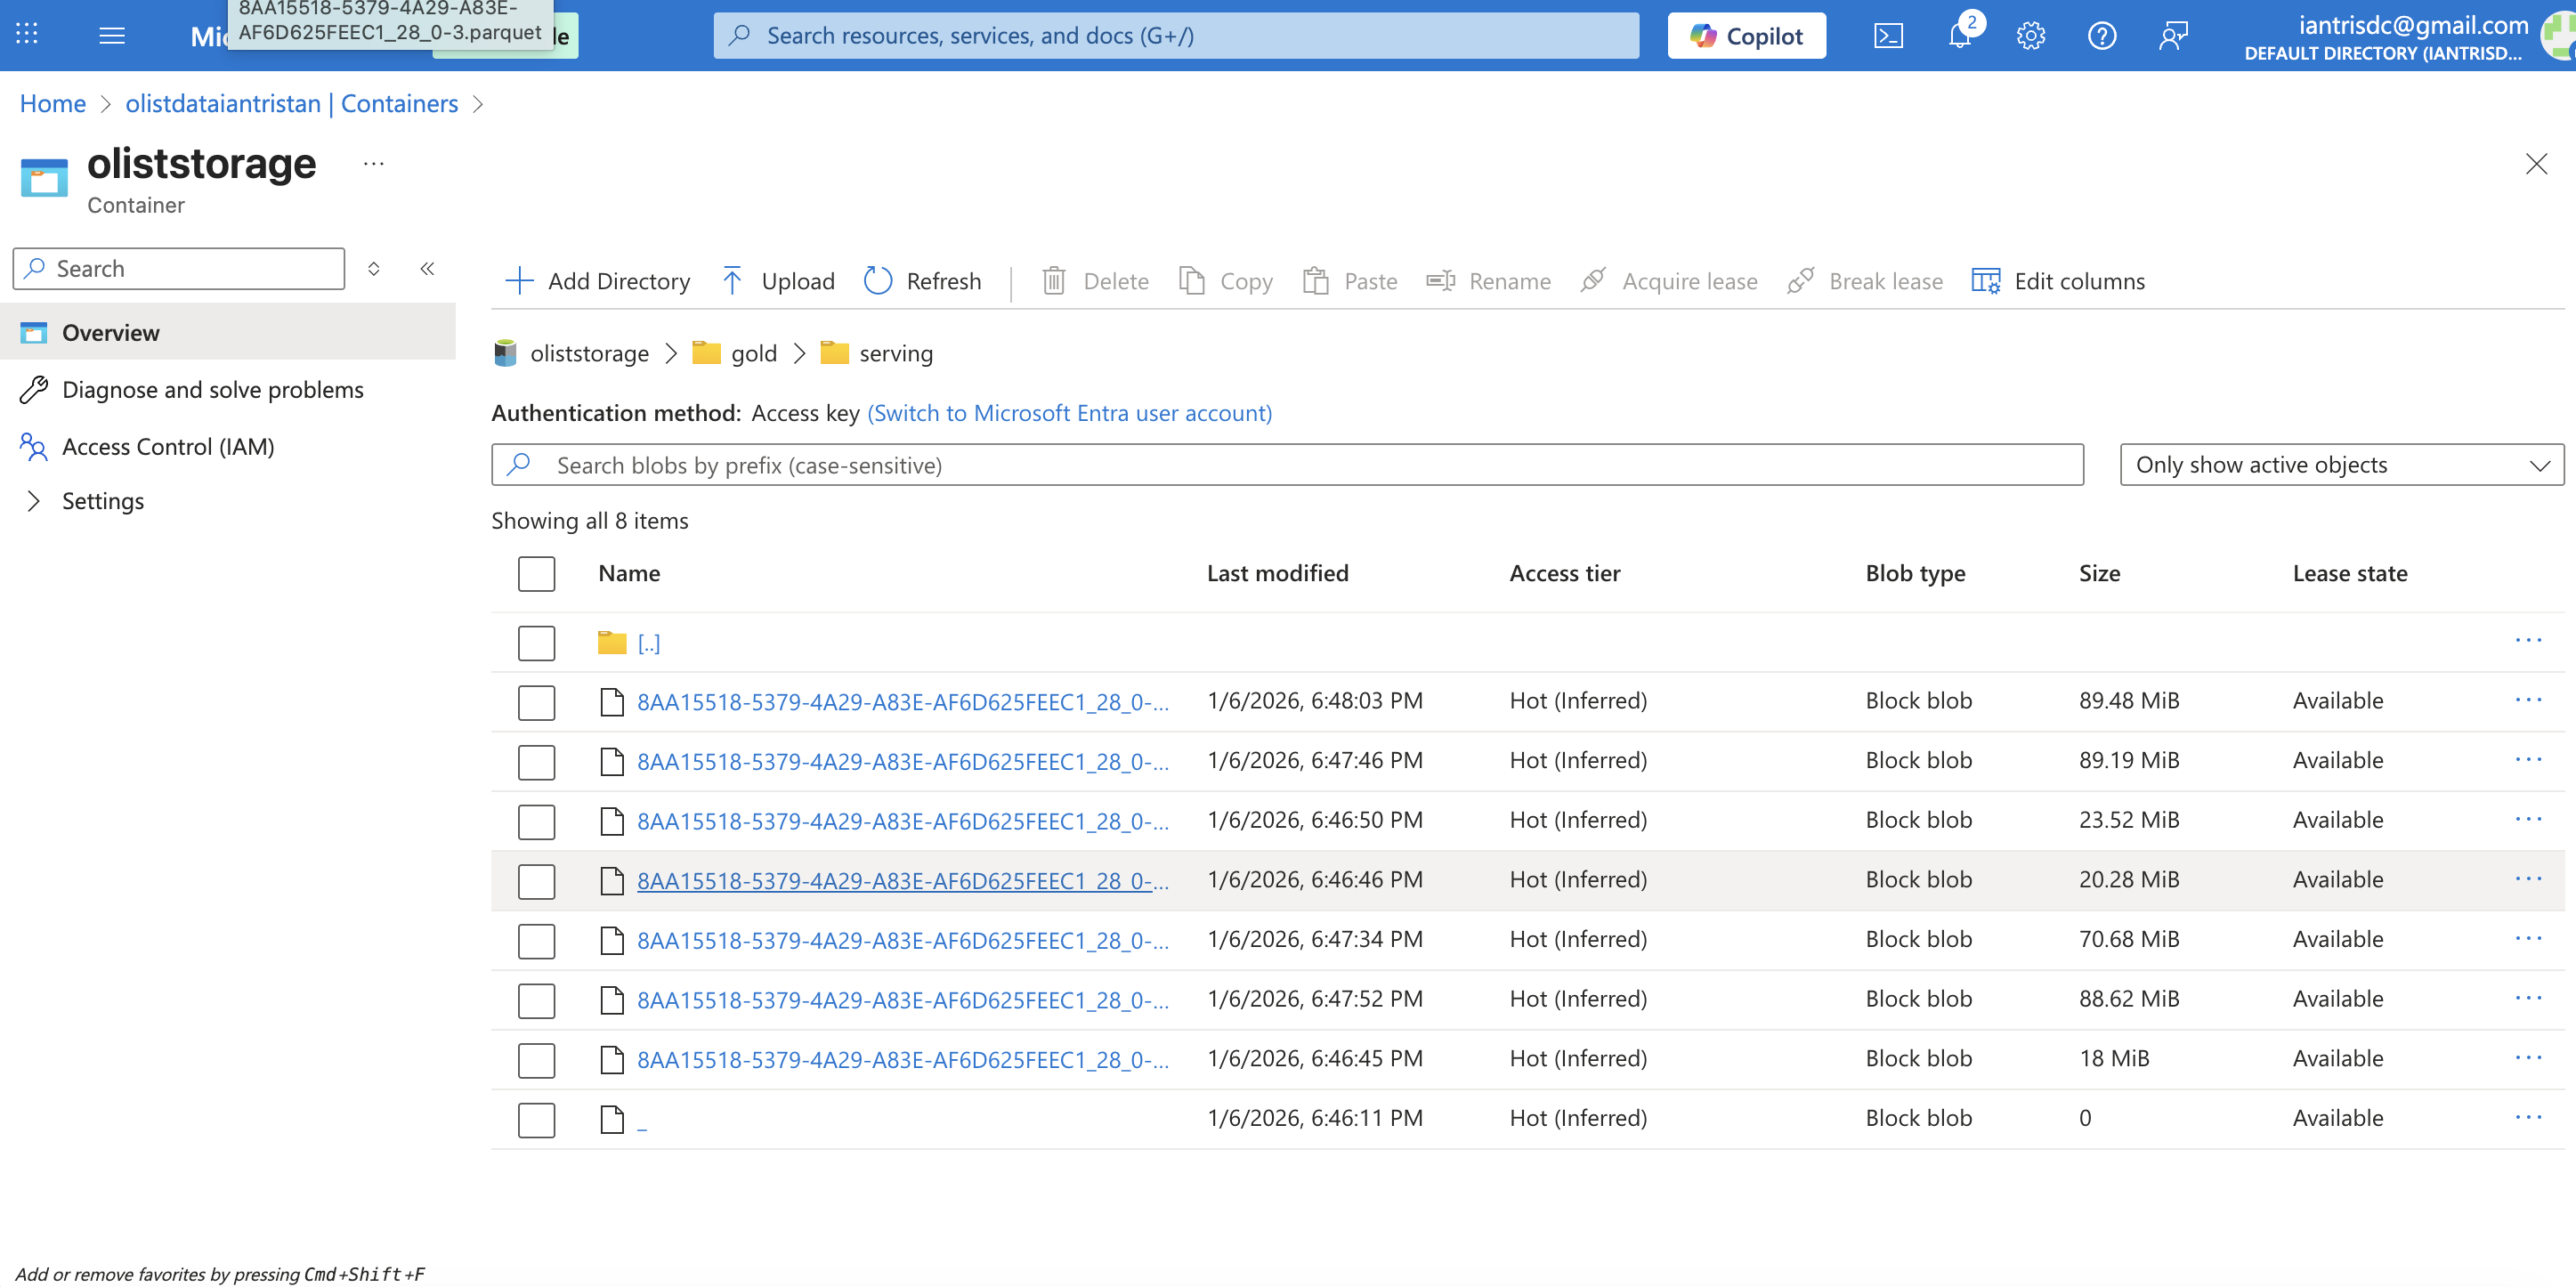